# RFM analysis

In [55]:
from datetime import datetime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings 
warnings.filterwarnings('ignore')

In [56]:
df = pd.read_csv('../data/rfm_data.csv', encoding='Latin-1')

In [57]:
df.head()

,CustomerID,PurchaseDate,TransactionAmount,ProductInformation,OrderID,Location
0,8814,2023-04-11,943.31,Product C,890075,Tokyo
1,2188,2023-04-11,463.70,Product A,176819,London
2,4608,2023-04-11,80.28,Product A,340062,New York
3,2559,2023-04-11,221.29,Product A,239145,London
4,9482,2023-04-11,739.56,Product A,194545,Paris


In [58]:
df.dtypes

CustomerID              int64
PurchaseDate           object
TransactionAmount     float64
ProductInformation     object
OrderID                 int64
Location               object
dtype: object

In [59]:
# Prepare variables for RFM analysis
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])
reference_date = df['PurchaseDate'].max() + pd.Timedelta(days=1)

# Customer ID as string
df['CustomerID'] = df['CustomerID'].astype(str)

# Revenue variable
df['Revenue'] = df['TransactionAmount']  

In [60]:
df.head()

,CustomerID,PurchaseDate,TransactionAmount,ProductInformation,OrderID,Location,Revenue
0,8814,2023-04-11,943.31,Product C,890075,Tokyo,943.31
1,2188,2023-04-11,463.70,Product A,176819,London,463.70
2,4608,2023-04-11,80.28,Product A,340062,New York,80.28
3,2559,2023-04-11,221.29,Product A,239145,London,221.29
4,9482,2023-04-11,739.56,Product A,194545,Paris,739.56


In [61]:
# Calculate RFM metrics
rfm_df = df.groupby('CustomerID').agg({
    'PurchaseDate': lambda v: (reference_date - v.max()).days,  # Recency
    'OrderID': 'count',  # Frequency
    'Revenue': 'sum'  # Monetary
})

In [62]:
rfm_df.rename(columns={
    'PurchaseDate': 'Recency',
    'OrderID': 'Frequency',
    'Revenue': 'Monetary'
})

,Recency,Frequency,Monetary
CustomerID,,,
1011,34,2,1129.02
1025,22,1,359.29
1029,1,1,704.99
1046,44,1,859.82
1049,14,1,225.72
...,...,...,...
9941,43,1,960.53
9950,39,1,679.11
9954,13,1,798.01


In [63]:
clustering = KMeans()
scale = StandardScaler()

In [64]:
rfm_cluster = pd.DataFrame(scale.fit_transform(rfm_df))
rfm_cluster.head()

,0,1,2
0,0.174294,3.844113,1.807528
1,-0.518974,-0.232715,-0.566637
2,-1.732192,-0.232715,0.499645
3,0.752017,-0.232715,0.977204
4,-0.981152,-0.232715,-0.978622


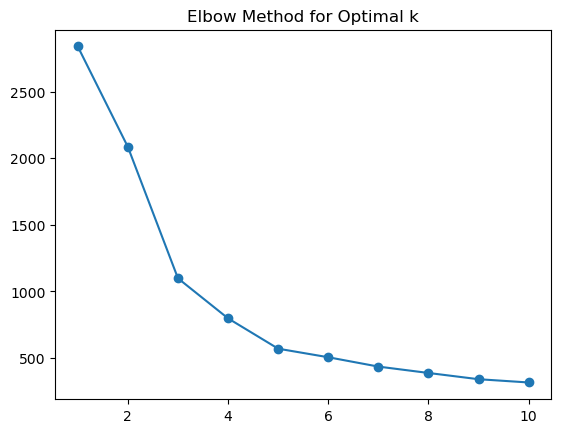

In [65]:
inertia_scores = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_cluster)
    inertia_scores.append(kmeans.inertia_)
plt.plot(range(1, 11), inertia_scores, marker='o')
plt.title('Elbow Method for Optimal k');

In [66]:
clustering_final = KMeans(n_clusters=5)
clustering_final.fit(rfm_cluster)
rfm_df['Cluster'] = clustering_final.labels_
rfm_df.head()


,PurchaseDate,OrderID,Revenue,Cluster
CustomerID,,,,
1011,34,2,1129.02,2
1025,22,1,359.29,1
1029,1,1,704.99,3
1046,44,1,859.82,4
1049,14,1,225.72,1


In [67]:
rfm_df.groupby('Cluster').mean()

,PurchaseDate,OrderID,Revenue
Cluster,,,
0,45.681416,1.000000,246.673982
1,14.074257,1.000000,260.434604
2,23.686275,2.058824,1072.476078
3,15.842857,1.000000,766.145524
4,45.167315,1.000000,738.267938
